In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [15]:
# Cell 2: Đọc dữ liệu
df = pd.read_csv("/content/drive/MyDrive/Hoc may va ung dung/DA/diamonds.csv")

# Xóa cột 'Unnamed: 0' nếu tồn tại
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(df.head())
print(df.info())
print(df.describe())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: f

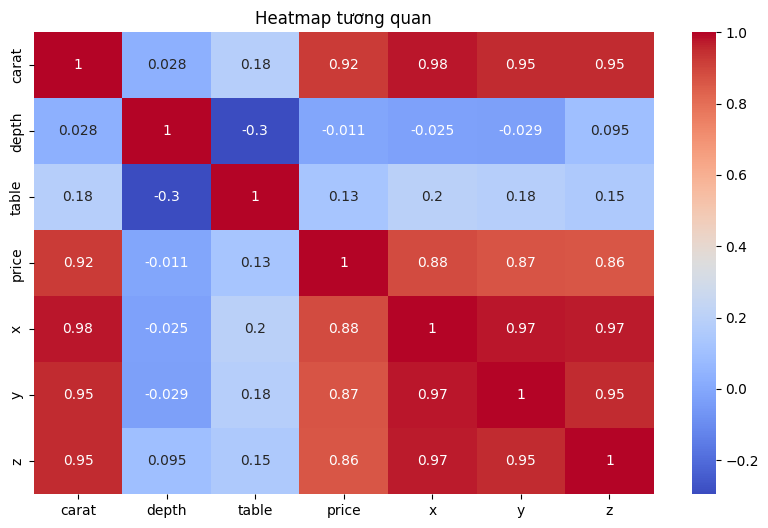

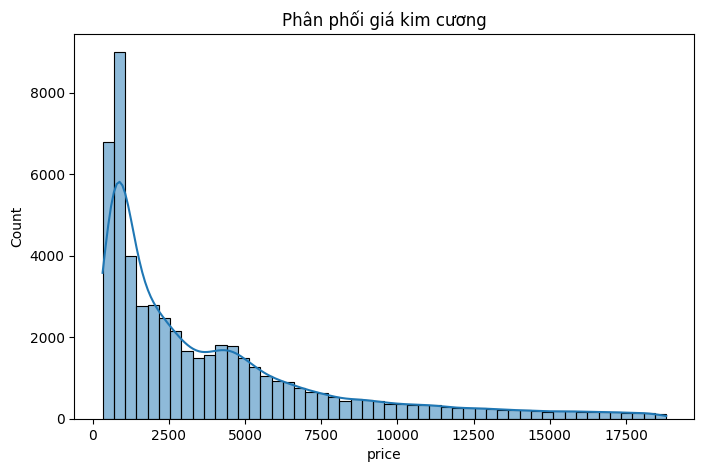

In [16]:
# Cell 3: EDA - Heatmap và phân phối giá
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Heatmap tương quan")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Phân phối giá kim cương")
plt.show()


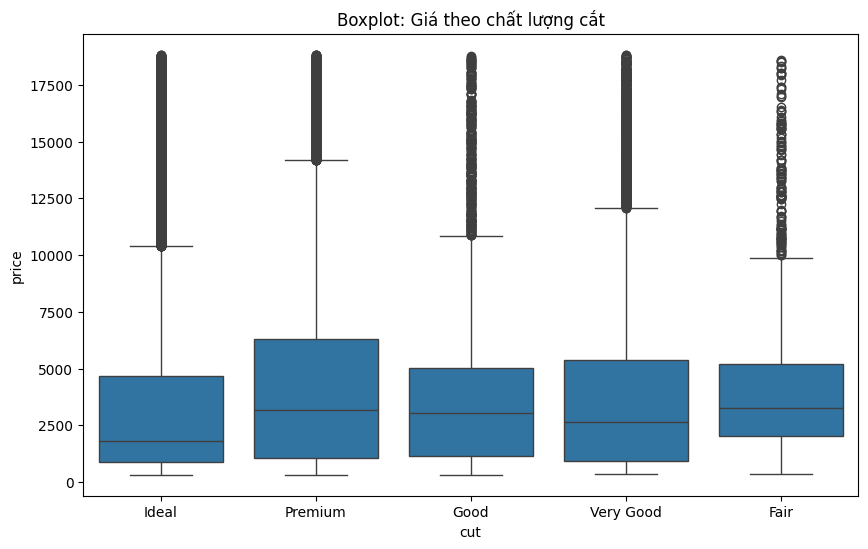

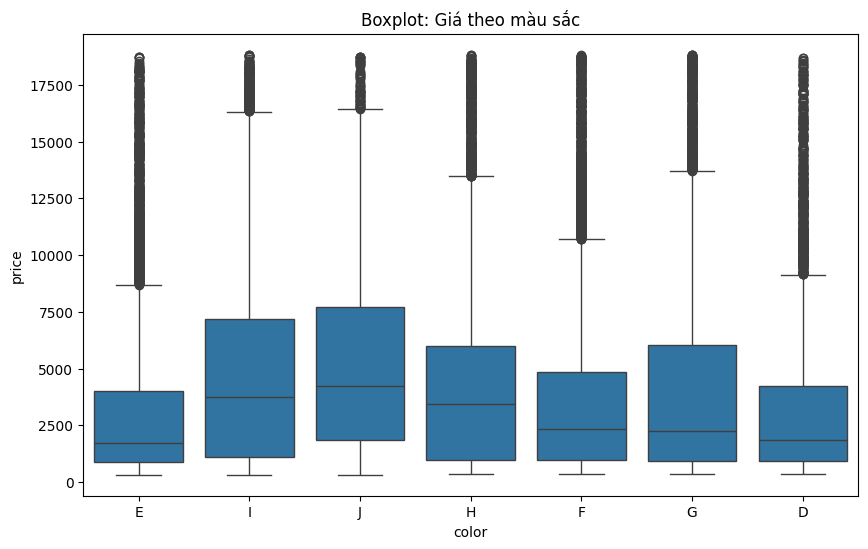

In [17]:
# Cell 4: EDA - Boxplot kiểm tra ngoại lai
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="cut", y="price")
plt.title("Boxplot: Giá theo chất lượng cắt")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="color", y="price")
plt.title("Boxplot: Giá theo màu sắc")
plt.show()


In [18]:
# Cell 5: Tiền xử lý dữ liệu
df = df.dropna()

# Mã hóa biến phân loại
le_cut = LabelEncoder()
le_color = LabelEncoder()
le_clarity = LabelEncoder()

df["cut"] = le_cut.fit_transform(df["cut"])
df["color"] = le_color.fit_transform(df["color"])
df["clarity"] = le_clarity.fit_transform(df["clarity"])

# Tách X, y
X = df.drop("price", axis=1)
y = df["price"]

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# Cell 6: Huấn luyện mô hình Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [20]:
# --- Cell 7 : Huấn luyện XGBoost (đặt eval_metric trong constructor) ---
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",      # <- đặt ở đây thay vì truyền vào fit()
    random_state=42,
    n_jobs=-1
)

# Gọi fit với eval_set (để lưu lịch sử RMSE)
# lưu ý truyền cả train và test nếu muốn thấy cả hai đường
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb.predict(X_test)


Random Forest - R2: 0.9818, MSE: 289186.34, RMSE: 537.76
XGBoost - R2: 0.9807, MSE: 307500.47, RMSE: 554.53
           Model        R2            MSE        RMSE
0  Random Forest  0.981809  289186.341199  537.760487
1        XGBoost  0.980657  307500.468750  554.527248


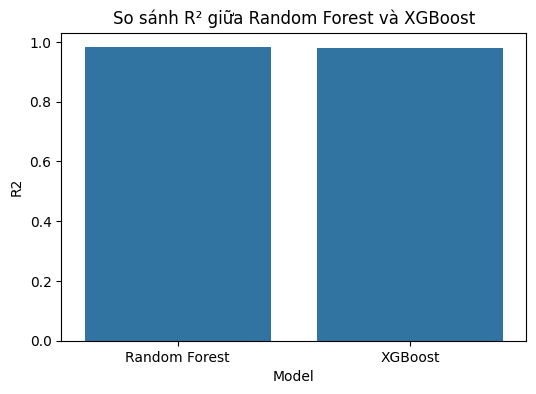

In [21]:
# Cell 8: Đánh giá mô hình
def eval_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{model_name} - R2: {r2:.4f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
    return [model_name, r2, mse, rmse]

results = []
results.append(eval_model(y_test, y_pred_rf, "Random Forest"))
results.append(eval_model(y_test, y_pred_xgb, "XGBoost"))

df_results = pd.DataFrame(results, columns=["Model", "R2", "MSE", "RMSE"])
print(df_results)

# Bar chart so sánh R2
plt.figure(figsize=(6,4))
sns.barplot(data=df_results, x="Model", y="R2")
plt.title("So sánh R² giữa Random Forest và XGBoost")
plt.show()


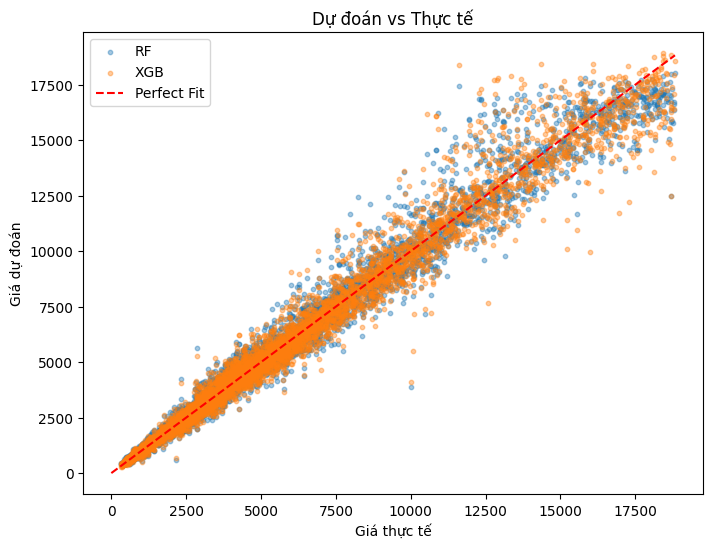

In [22]:
# Cell 9: Biểu đồ Dự đoán vs Thực tế
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, label="RF", s=10)
plt.scatter(y_test, y_pred_xgb, alpha=0.4, label="XGB", s=10)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', label="Perfect Fit")
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("Dự đoán vs Thực tế")
plt.legend()
plt.show()


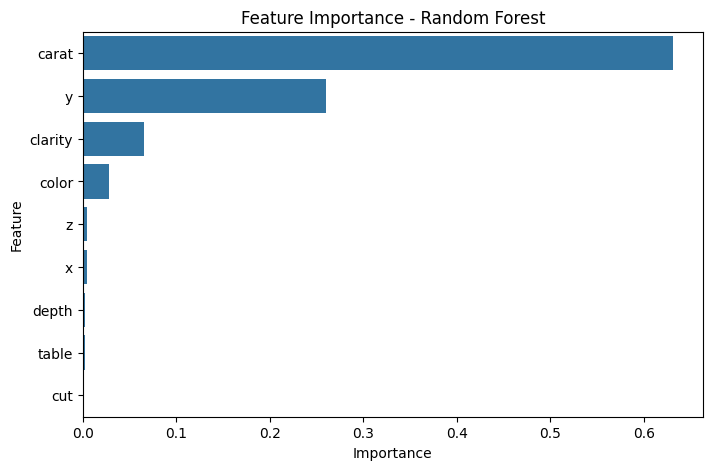

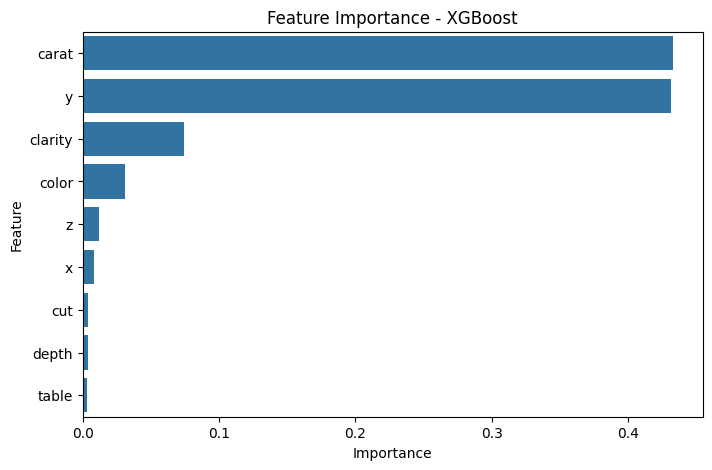

In [23]:
# Cell 10: Feature Importance
# Random Forest
importances_rf = rf.feature_importances_
feat_rf = pd.DataFrame({"Feature": X.columns, "Importance": importances_rf}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feat_rf, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

# XGBoost
importances_xgb = xgb.feature_importances_
feat_xgb = pd.DataFrame({"Feature": X.columns, "Importance": importances_xgb}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feat_xgb, x="Importance", y="Feature")
plt.title("Feature Importance - XGBoost")
plt.show()


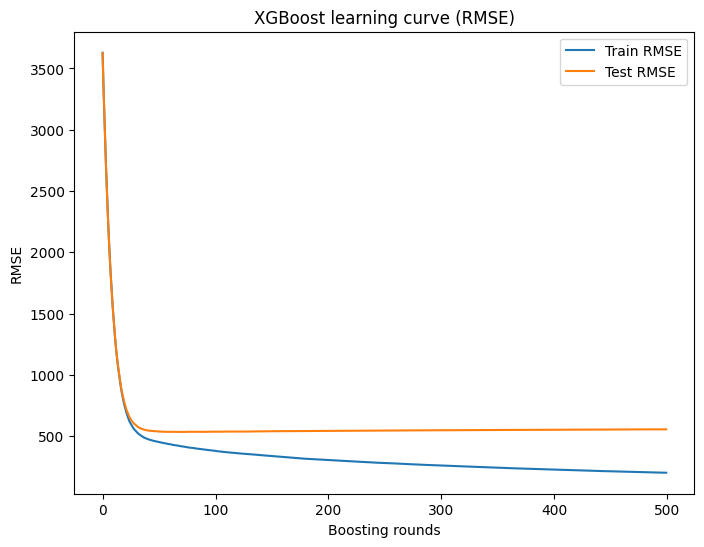

In [24]:
# --- Cell 11: Vẽ Learning Curve từ evals_result() ---
evals_res = xgb.evals_result()   # <- gọi trực tiếp từ wrapper
train_rmse = evals_res['validation_0']['rmse']
test_rmse  = evals_res['validation_1']['rmse']

plt.figure(figsize=(8,6))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(test_rmse, label='Test RMSE')
plt.xlabel('Boosting rounds')
plt.ylabel('RMSE')
plt.title('XGBoost learning curve (RMSE)')
plt.legend()
plt.show()
